## 1. Imports

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(tf.__version__)
import os
import pandas as pd
import matplotlib.pyplot as plt

2.20.0


## 2. Load Data

In [13]:
import pandas as pd
import tensorflow as tf

# load the split files
train_df = pd.read_csv("splits/train.csv")
val_df = pd.read_csv("splits/val.csv")
test_df = pd.read_csv("splits/test.csv")

# get all unique author names from the training set
authors = sorted(train_df["author"].unique())

# create a dictionary: author name -> number
author_to_idx = {author: i for i, author in enumerate(authors)}

# create a new numeric label column
train_df["label"] = train_df["author"].map(author_to_idx)
val_df["label"] = val_df["author"].map(author_to_idx)
test_df["label"] = test_df["author"].map(author_to_idx)

# create TensorFlow datasets from file paths and numeric labels
train_ds = tf.data.Dataset.from_tensor_slices((
    train_df["image_path"].values,
    train_df["label"].values
))

val_ds = tf.data.Dataset.from_tensor_slices((
    val_df["image_path"].values,
    val_df["label"].values
))

test_ds = tf.data.Dataset.from_tensor_slices((
    test_df["image_path"].values,
    test_df["label"].values
))

## 3. Preprocessing

## 3.1 Picture size

First we want to check, if the picture sizes align.

In [14]:
from PIL import Image

size_dict = {}

for path in train_df["image_path"]:
    try:
        img = Image.open(path)
        size = img.size  # (width, height)

        # count how often each size appears
        if size in size_dict:
            size_dict[size] += 1
        else:
            size_dict[size] = 1

    except:
        continue

# print all sizes (sorted)
print("All image sizes:")
for size in sorted(size_dict):
    print(size, "->", size_dict[size])

All image sizes:
(512, 512) -> 10805


We can see, that all pictures have the same size: 512, 512.

Since this is rather big, we might have to resize them later on.

## 3.2 Normalize

In [15]:
def load_and_normalize(path, label):
    # read image file from disk
    img = tf.io.read_file(path)

    # decode image into RGB
    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    # convert pixel values from 0-255 to 0-1
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

In [16]:
train_ds = train_ds.map(load_and_normalize)
val_ds = val_ds.map(load_and_normalize)
test_ds = test_ds.map(load_and_normalize)

### *Intermediate step: Check if everything worked so far.*

In [17]:
for img, label in train_ds.take(1):
    print("Shape:", img.shape)
    print("Min pixel:", tf.reduce_min(img).numpy())
    print("Max pixel:", tf.reduce_max(img).numpy())
    print("Label:", label.numpy())

Shape: (512, 512, 3)
Min pixel: 0.0
Max pixel: 0.9529412
Label: 22


Working label for author and normailzation worked as well (values between 0 and 1)

## 3.3 Augmentation

In [18]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
])

Now we apply our augmentation to a picture a few times to check if it works

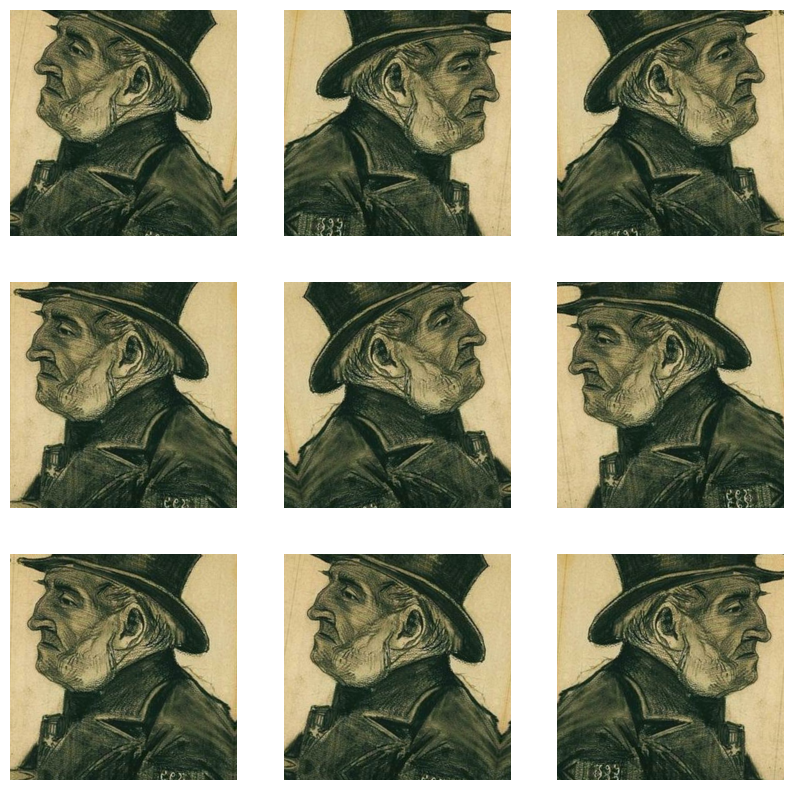

In [19]:
# take one normalized image from the training dataset
for img, label in train_ds.take(1):
    sample_img = img
    break

plt.figure(figsize=(10, 10))

for i in range(9):
    # apply augmentation in training mode
    augmented_img = data_augmentation(tf.expand_dims(sample_img, axis=0), training=True)

    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_img[0].numpy())
    plt.axis("off")

plt.show()

It seems to work fine, you can clearly see small differences between the pictures.

## 3.4 Batching

In [20]:
BATCH_SIZE = 64

In [21]:
train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

In [22]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (64, 512, 512, 3)
Labels shape: (64,)
